# Data Exploration

In [147]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import numpy as np
import scipy.stats as stats

## References to use
- https://www.kaggle.com/code/juliencs/a-study-on-regression-applied-to-the-ames-dataset
- https://www.kaggle.com/code/dgawlik/house-prices-eda#Price-Segments

In [148]:
# PATH DEFINITIONS
BASE_DIR = Path().resolve().parent

DATA_DIR = BASE_DIR / "data"
RAW_DATA_DIR = DATA_DIR / "data_raw"

EDA_DATA_DIR = DATA_DIR / "data_eda"
EDA_DATA_DIR.mkdir(exist_ok=True)

In [149]:
# LOAD THE DATASET
df_raw = pd.read_csv(RAW_DATA_DIR / "train.csv")
df = df_raw.copy()

In [150]:
# DATASET OVERVIEW
pd.set_option('display.max_columns', None)
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [151]:
# CHECK NUMBER OF ROWS AND COLUMNS
df.shape

(1460, 81)

In [152]:
# CHECK COLUMN NAMES (SPACES, CASING, WEIRD CHARACTERS?) 

df.columns = df.columns.str.upper()
columns_str = df.select_dtypes(include='string')

for col in columns_str.columns:
    df[col] = df[col].str.upper()

df.head()

,ID,MSSUBCLASS,MSZONING,LOTFRONTAGE,LOTAREA,STREET,ALLEY,LOTSHAPE,LANDCONTOUR,UTILITIES,LOTCONFIG,LANDSLOPE,NEIGHBORHOOD,CONDITION1,CONDITION2,BLDGTYPE,HOUSESTYLE,OVERALLQUAL,OVERALLCOND,YEARBUILT,YEARREMODADD,ROOFSTYLE,ROOFMATL,EXTERIOR1ST,EXTERIOR2ND,MASVNRTYPE,MASVNRAREA,EXTERQUAL,EXTERCOND,FOUNDATION,BSMTQUAL,BSMTCOND,BSMTEXPOSURE,BSMTFINTYPE1,BSMTFINSF1,BSMTFINTYPE2,BSMTFINSF2,BSMTUNFSF,TOTALBSMTSF,HEATING,HEATINGQC,CENTRALAIR,ELECTRICAL,1STFLRSF,2NDFLRSF,LOWQUALFINSF,GRLIVAREA,BSMTFULLBATH,BSMTHALFBATH,FULLBATH,HALFBATH,BEDROOMABVGR,KITCHENABVGR,KITCHENQUAL,TOTRMSABVGRD,FUNCTIONAL,FIREPLACES,FIREPLACEQU,GARAGETYPE,GARAGEYRBLT,GARAGEFINISH,GARAGECARS,GARAGEAREA,GARAGEQUAL,GARAGECOND,PAVEDDRIVE,WOODDECKSF,OPENPORCHSF,ENCLOSEDPORCH,3SSNPORCH,SCREENPORCH,POOLAREA,POOLQC,FENCE,MISCFEATURE,MISCVAL,MOSOLD,YRSOLD,SALETYPE,SALECONDITION,SALEPRICE
0,1,60,RL,65.0,8450,PAVE,NaN,REG,LVL,ALLPUB,INSIDE,GTL,COLLGCR,NORM,NORM,1FAM,2STORY,7,5,2003,2003,GABLE,COMPSHG,VINYLSD,VINYLSD,BRKFACE,196.0,GD,TA,PCONC,GD,TA,NO,GLQ,706,UNF,0,150,856,GASA,EX,Y,SBRKR,856,854,0,1710,1,0,2,1,3,1,GD,8,TYP,0,NaN,ATTCHD,2003.0,RFN,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,NORMAL,208500
1,2,20,RL,80.0,9600,PAVE,NaN,REG,LVL,ALLPUB,FR2,GTL,VEENKER,FEEDR,NORM,1FAM,1STORY,6,8,1976,1976,GABLE,COMPSHG,METALSD,METALSD,NaN,0.0,TA,TA,CBLOCK,GD,TA,GD,ALQ,978,UNF,0,284,1262,GASA,EX,Y,SBRKR,1262,0,0,1262,0,1,2,0,3,1,TA,6,TYP,1,TA,ATTCHD,1976.0,RFN,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,NORMAL,181500
2,3,60,RL,68.0,11250,PAVE,NaN,IR1,LVL,ALLPUB,INSIDE,GTL,COLLGCR,NORM,NORM,1FAM,2STORY,7,5,2001,2002,GABLE,COMPSHG,VINYLSD,VINYLSD,BRKFACE,162.0,GD,TA,PCONC,GD,TA,MN,GLQ,486,UNF,0,434,920,GASA,EX,Y,SBRKR,920,866,0,1786,1,0,2,1,3,1,GD,6,TYP,1,TA,ATTCHD,2001.0,RFN,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,NORMAL,223500
3,4,70,RL,60.0,9550,PAVE,NaN,IR1,LVL,ALLPUB,CORNER,GTL,CRAWFOR,NORM,NORM,1FAM,2STORY,7,5,1915,1970,GABLE,COMPSHG,WD SDNG,WD SHNG,NaN,0.0,TA,TA,BRKTIL,TA,GD,NO,ALQ,216,UNF,0,540,756,GASA,GD,Y,SBRKR,961,756,0,1717,1,0,1,0,3,1,GD,7,TYP,1,GD,DETCHD,1998.0,UNF,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,ABNORML,140000
4,5,60,RL,84.0,14260,PAVE,NaN,IR1,LVL,ALLPUB,FR2,GTL,NORIDGE,NORM,NORM,1FAM,2STORY,8,5,2000,2000,GABLE,COMPSHG,VINYLSD,VINYLSD,BRKFACE,350.0,GD,TA,PCONC,GD,TA,AV,GLQ,655,UNF,0,490,1145,GASA,EX,Y,SBRKR,1145,1053,0,2198,1,0,2,1,4,1,GD,9,TYP,1,TA,ATTCHD,2000.0,RFN,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,NORMAL,250000


The columns: `1STFLRSF`, `2NDFLRSF`, `3SSNPORCH` start with a number, can become a problem on the future

## 2. First look at the data

In [153]:
# VIEW THE FIRST FEW ROWS
df.head()

,ID,MSSUBCLASS,MSZONING,LOTFRONTAGE,LOTAREA,STREET,ALLEY,LOTSHAPE,LANDCONTOUR,UTILITIES,LOTCONFIG,LANDSLOPE,NEIGHBORHOOD,CONDITION1,CONDITION2,BLDGTYPE,HOUSESTYLE,OVERALLQUAL,OVERALLCOND,YEARBUILT,YEARREMODADD,ROOFSTYLE,ROOFMATL,EXTERIOR1ST,EXTERIOR2ND,MASVNRTYPE,MASVNRAREA,EXTERQUAL,EXTERCOND,FOUNDATION,BSMTQUAL,BSMTCOND,BSMTEXPOSURE,BSMTFINTYPE1,BSMTFINSF1,BSMTFINTYPE2,BSMTFINSF2,BSMTUNFSF,TOTALBSMTSF,HEATING,HEATINGQC,CENTRALAIR,ELECTRICAL,1STFLRSF,2NDFLRSF,LOWQUALFINSF,GRLIVAREA,BSMTFULLBATH,BSMTHALFBATH,FULLBATH,HALFBATH,BEDROOMABVGR,KITCHENABVGR,KITCHENQUAL,TOTRMSABVGRD,FUNCTIONAL,FIREPLACES,FIREPLACEQU,GARAGETYPE,GARAGEYRBLT,GARAGEFINISH,GARAGECARS,GARAGEAREA,GARAGEQUAL,GARAGECOND,PAVEDDRIVE,WOODDECKSF,OPENPORCHSF,ENCLOSEDPORCH,3SSNPORCH,SCREENPORCH,POOLAREA,POOLQC,FENCE,MISCFEATURE,MISCVAL,MOSOLD,YRSOLD,SALETYPE,SALECONDITION,SALEPRICE
0,1,60,RL,65.0,8450,PAVE,NaN,REG,LVL,ALLPUB,INSIDE,GTL,COLLGCR,NORM,NORM,1FAM,2STORY,7,5,2003,2003,GABLE,COMPSHG,VINYLSD,VINYLSD,BRKFACE,196.0,GD,TA,PCONC,GD,TA,NO,GLQ,706,UNF,0,150,856,GASA,EX,Y,SBRKR,856,854,0,1710,1,0,2,1,3,1,GD,8,TYP,0,NaN,ATTCHD,2003.0,RFN,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,NORMAL,208500
1,2,20,RL,80.0,9600,PAVE,NaN,REG,LVL,ALLPUB,FR2,GTL,VEENKER,FEEDR,NORM,1FAM,1STORY,6,8,1976,1976,GABLE,COMPSHG,METALSD,METALSD,NaN,0.0,TA,TA,CBLOCK,GD,TA,GD,ALQ,978,UNF,0,284,1262,GASA,EX,Y,SBRKR,1262,0,0,1262,0,1,2,0,3,1,TA,6,TYP,1,TA,ATTCHD,1976.0,RFN,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,NORMAL,181500
2,3,60,RL,68.0,11250,PAVE,NaN,IR1,LVL,ALLPUB,INSIDE,GTL,COLLGCR,NORM,NORM,1FAM,2STORY,7,5,2001,2002,GABLE,COMPSHG,VINYLSD,VINYLSD,BRKFACE,162.0,GD,TA,PCONC,GD,TA,MN,GLQ,486,UNF,0,434,920,GASA,EX,Y,SBRKR,920,866,0,1786,1,0,2,1,3,1,GD,6,TYP,1,TA,ATTCHD,2001.0,RFN,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,NORMAL,223500
3,4,70,RL,60.0,9550,PAVE,NaN,IR1,LVL,ALLPUB,CORNER,GTL,CRAWFOR,NORM,NORM,1FAM,2STORY,7,5,1915,1970,GABLE,COMPSHG,WD SDNG,WD SHNG,NaN,0.0,TA,TA,BRKTIL,TA,GD,NO,ALQ,216,UNF,0,540,756,GASA,GD,Y,SBRKR,961,756,0,1717,1,0,1,0,3,1,GD,7,TYP,1,GD,DETCHD,1998.0,UNF,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,ABNORML,140000
4,5,60,RL,84.0,14260,PAVE,NaN,IR1,LVL,ALLPUB,FR2,GTL,NORIDGE,NORM,NORM,1FAM,2STORY,8,5,2000,2000,GABLE,COMPSHG,VINYLSD,VINYLSD,BRKFACE,350.0,GD,TA,PCONC,GD,TA,AV,GLQ,655,UNF,0,490,1145,GASA,EX,Y,SBRKR,1145,1053,0,2198,1,0,2,1,4,1,GD,9,TYP,1,TA,ATTCHD,2000.0,RFN,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,NORMAL,250000


In [154]:
# VIEW A RANDOM SAMPLE OF ROWS 

df.sample(n=5) # You can define a random_state, if you prefer...

,ID,MSSUBCLASS,MSZONING,LOTFRONTAGE,LOTAREA,STREET,ALLEY,LOTSHAPE,LANDCONTOUR,UTILITIES,LOTCONFIG,LANDSLOPE,NEIGHBORHOOD,CONDITION1,CONDITION2,BLDGTYPE,HOUSESTYLE,OVERALLQUAL,OVERALLCOND,YEARBUILT,YEARREMODADD,ROOFSTYLE,ROOFMATL,EXTERIOR1ST,EXTERIOR2ND,MASVNRTYPE,MASVNRAREA,EXTERQUAL,EXTERCOND,FOUNDATION,BSMTQUAL,BSMTCOND,BSMTEXPOSURE,BSMTFINTYPE1,BSMTFINSF1,BSMTFINTYPE2,BSMTFINSF2,BSMTUNFSF,TOTALBSMTSF,HEATING,HEATINGQC,CENTRALAIR,ELECTRICAL,1STFLRSF,2NDFLRSF,LOWQUALFINSF,GRLIVAREA,BSMTFULLBATH,BSMTHALFBATH,FULLBATH,HALFBATH,BEDROOMABVGR,KITCHENABVGR,KITCHENQUAL,TOTRMSABVGRD,FUNCTIONAL,FIREPLACES,FIREPLACEQU,GARAGETYPE,GARAGEYRBLT,GARAGEFINISH,GARAGECARS,GARAGEAREA,GARAGEQUAL,GARAGECOND,PAVEDDRIVE,WOODDECKSF,OPENPORCHSF,ENCLOSEDPORCH,3SSNPORCH,SCREENPORCH,POOLAREA,POOLQC,FENCE,MISCFEATURE,MISCVAL,MOSOLD,YRSOLD,SALETYPE,SALECONDITION,SALEPRICE
998,999,30,RM,60.0,9786,PAVE,NaN,REG,LVL,ALLPUB,INSIDE,GTL,IDOTRR,NORM,NORM,1FAM,1STORY,3,4,1922,1950,HIP,COMPSHG,WD SDNG,WD SDNG,NaN,0.0,TA,TA,BRKTIL,TA,FA,NO,UNF,0,UNF,0,1007,1007,GASA,FA,N,SBRKR,1077,0,0,1077,0,0,1,0,3,1,TA,6,TYP,1,GD,DETCHD,1922.0,UNF,1,210,TA,FA,P,0,100,48,0,0,0,NaN,NaN,NaN,0,5,2006,WD,NORMAL,91000
869,870,60,RL,80.0,9938,PAVE,NaN,REG,LVL,ALLPUB,INSIDE,GTL,SAWYERW,NORM,NORM,1FAM,2STORY,7,5,1993,1994,GABLE,COMPSHG,METALSD,METALSD,BRKFACE,246.0,GD,TA,PCONC,GD,TA,NO,GLQ,750,UNF,0,300,1050,GASA,EX,Y,SBRKR,1062,887,0,1949,1,0,2,1,3,1,GD,8,TYP,1,TA,ATTCHD,1993.0,FIN,2,574,TA,TA,Y,156,90,0,0,0,0,NaN,GDPRV,NaN,0,6,2010,WD,NORMAL,236000
870,871,20,RL,60.0,6600,PAVE,NaN,REG,LVL,ALLPUB,INSIDE,GTL,NAMES,POSN,NORM,1FAM,1STORY,5,5,1962,1962,HIP,COMPSHG,METALSD,METALSD,NaN,0.0,TA,TA,CBLOCK,TA,TA,NO,UNF,0,UNF,0,894,894,GASA,GD,N,SBRKR,894,0,0,894,0,0,1,0,2,1,TA,5,TYP,0,NaN,DETCHD,1962.0,UNF,1,308,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,8,2009,WD,NORMAL,109500
613,614,20,RL,70.0,8402,PAVE,NaN,REG,LVL,ALLPUB,INSIDE,GTL,MITCHEL,FEEDR,NORM,1FAM,1STORY,5,5,2007,2007,GABLE,COMPSHG,VINYLSD,VINYLSD,NaN,0.0,TA,TA,PCONC,GD,TA,NO,ALQ,206,UNF,0,914,1120,GASA,EX,Y,SBRKR,1120,0,0,1120,0,0,1,0,3,1,TA,6,TYP,0,NaN,NaN,NaN,NaN,0,0,NaN,NaN,Y,0,30,0,0,0,0,NaN,NaN,NaN,0,12,2007,NEW,PARTIAL,147000
1028,1029,50,RL,79.0,9492,PAVE,NaN,REG,LVL,ALLPUB,INSIDE,GTL,NAMES,ARTERY,NORM,1FAM,1.5FIN,5,5,1941,1950,GABLE,COMPSHG,WDSHING,WD SHNG,NaN,0.0,TA,TA,CBLOCK,TA,TA,NO,REC,368,BLQ,41,359,768,GASA,TA,Y,SBRKR,968,408,0,1376,1,0,1,0,3,1,TA,6,TYP,1,GD,ATTCHD,1941.0,UNF,1,240,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,4,2007,WD,NORMAL,105000


In [155]:
# CHECK DTYPES OF EVERY COLUMN

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             1460 non-null   int64  
 1   MSSUBCLASS     1460 non-null   int64  
 2   MSZONING       1460 non-null   str    
 3   LOTFRONTAGE    1201 non-null   float64
 4   LOTAREA        1460 non-null   int64  
 5   STREET         1460 non-null   str    
 6   ALLEY          91 non-null     str    
 7   LOTSHAPE       1460 non-null   str    
 8   LANDCONTOUR    1460 non-null   str    
 9   UTILITIES      1460 non-null   str    
 10  LOTCONFIG      1460 non-null   str    
 11  LANDSLOPE      1460 non-null   str    
 12  NEIGHBORHOOD   1460 non-null   str    
 13  CONDITION1     1460 non-null   str    
 14  CONDITION2     1460 non-null   str    
 15  BLDGTYPE       1460 non-null   str    
 16  HOUSESTYLE     1460 non-null   str    
 17  OVERALLQUAL    1460 non-null   int64  
 18  OVERALLCOND    1460

**FLAGGED COLUMNS BY TYPE:** 

**float64 → int64.:** `GARAGEYRBLT` — a year is always a int

**int64 → float64 (area measurements).** Area measurements are continuous in nature: `LOTAREA`, `BSMTFINSF1`, `BSMTFINSF2`, `BSMTUNFSF`, `TOTALBSMTSF`, `1STFLRSF`, `2NDFLRSF`, `LOWQUALFINSF`, `GRLIVAREA`, `GARAGEAREA`, `WOODDECKSF`, `OPENPORCHSF`, `ENCLOSEDPORCH`, `3SSNPORCH`, `SCREENPORCH`, `POOLAREA`

**Deferred — convert to category in a later step.** These columns encode ordinal or nominal categories, not quantities: `MSSUBCLASS`, `OVERALLQUAL`, `OVERALLCOND`, `MOSOLD`, `YRSOLD`

**Notes**
- Do not convert `GARAGEYRBLT` before imputation — casting a nullable column to int64 raises an error if nulls remain. Use `pd.Int64Dtype()` as an intermediate step if needed.
- Area columns with all-zero values (e.g. `POOLAREA`, `3SSNPORCH`) are semantically valid as float — zero simply means the feature is absent.

## 3. Quantify missing data


In [156]:
# NULLS PER COLUMN AND PERCENTAGE OF NULLS PER COLUMN

nulls_per_column = df.isnull().sum()
percentage_nulls_per_column = df.isnull().mean()
nulls_per_column = pd.DataFrame(nulls_per_column)
nulls_per_column = nulls_per_column.rename(columns={0: 'SUM'})
nulls_per_column['%'] = percentage_nulls_per_column.round(4)*100
nulls_per_column = nulls_per_column.sort_values(by='SUM', ascending=False)

nulls_per_column[nulls_per_column['SUM'] > 0]


,SUM,%
POOLQC,1453,99.52
MISCFEATURE,1406,96.30
ALLEY,1369,93.77
FENCE,1179,80.75
MASVNRTYPE,872,59.73
FIREPLACEQU,690,47.26
LOTFRONTAGE,259,17.74
GARAGEQUAL,81,5.55
GARAGEFINISH,81,5.55
GARAGETYPE,81,5.55


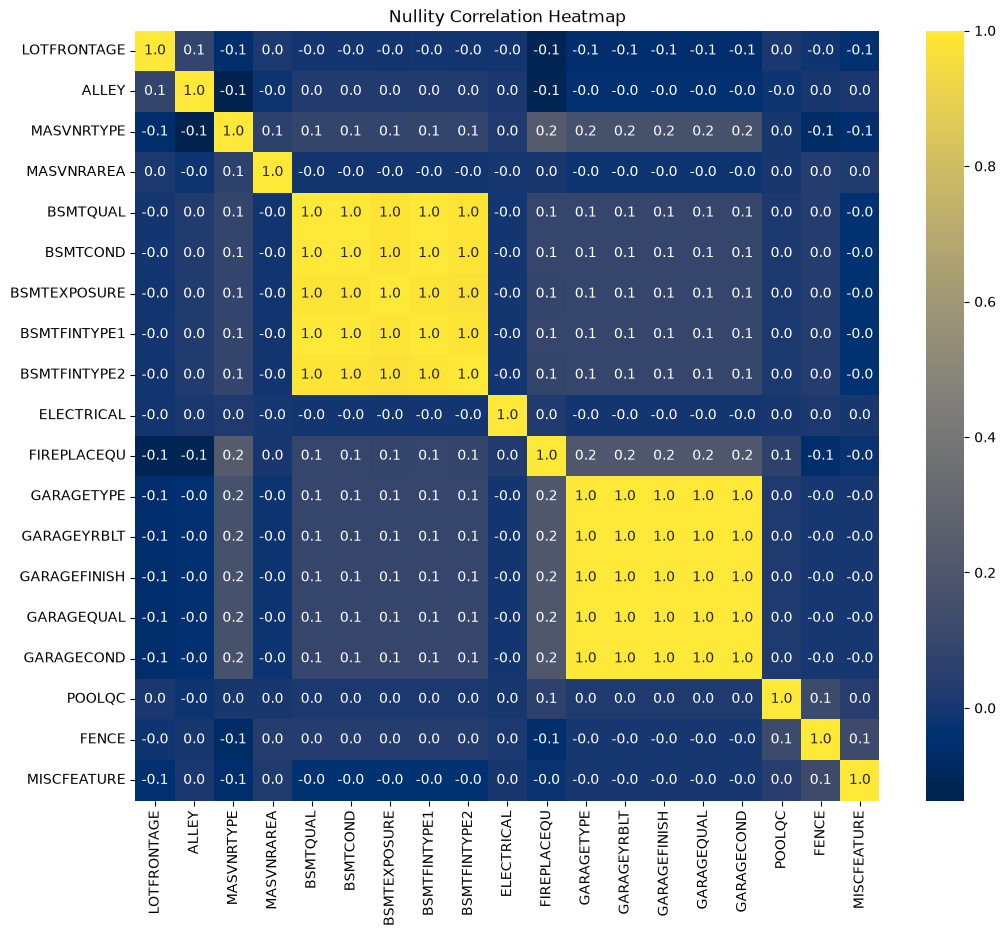

In [157]:
# CHECK IF MISSINGNESS CLUSTERS

zero_null_values = nulls_per_column[nulls_per_column['SUM'] == 0].index
nullity_correlation = df.isnull().corr()
nullity_correlation = nullity_correlation.drop(index=zero_null_values, columns=zero_null_values)

plt.figure(figsize=(12,10))
ax = plt.axes()

sns.heatmap(nullity_correlation, annot=True, fmt='.1f', cmap='cividis', ax=ax)
ax.set_title('Nullity Correlation Heatmap')
plt.show()

**ANALYSIS**: The columns related to **garage**, like GARAGEQUAL, GARAGEFINISH, GARAGETYPE, GARAGEYRBLT, and GARAGECOND, have a strong relation of occurrence. The same phenomenon occurs in columns related to **basement**: BSMTFINTYPE2, BSMTEXPOSURE, BSMTCOND, BSMTQUAL, and BSMTFINTYPE1.

This phenomenon may indicate that an issue occurred in data collection. A fair conclusion is that these null values indicate that there are properties without a garage and basement that are classified with NULL VALUES.

In [158]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             1460 non-null   int64  
 1   MSSUBCLASS     1460 non-null   int64  
 2   MSZONING       1460 non-null   str    
 3   LOTFRONTAGE    1201 non-null   float64
 4   LOTAREA        1460 non-null   int64  
 5   STREET         1460 non-null   str    
 6   ALLEY          91 non-null     str    
 7   LOTSHAPE       1460 non-null   str    
 8   LANDCONTOUR    1460 non-null   str    
 9   UTILITIES      1460 non-null   str    
 10  LOTCONFIG      1460 non-null   str    
 11  LANDSLOPE      1460 non-null   str    
 12  NEIGHBORHOOD   1460 non-null   str    
 13  CONDITION1     1460 non-null   str    
 14  CONDITION2     1460 non-null   str    
 15  BLDGTYPE       1460 non-null   str    
 16  HOUSESTYLE     1460 non-null   str    
 17  OVERALLQUAL    1460 non-null   int64  
 18  OVERALLCOND    1460

In [159]:
## CHECK FOR INVALID VALUES OF STRING COLUMNS

columns_str = df.select_dtypes(include='string')
for col in columns_str.columns:
   print(df[col].value_counts(), '\n')
   

MSZONING
RL         1151
RM          218
FV           65
RH           16
C (ALL)      10
Name: count, dtype: int64 

STREET
PAVE    1454
GRVL       6
Name: count, dtype: int64 

ALLEY
GRVL    50
PAVE    41
Name: count, dtype: int64 

LOTSHAPE
REG    925
IR1    484
IR2     41
IR3     10
Name: count, dtype: int64 

LANDCONTOUR
LVL    1311
BNK      63
HLS      50
LOW      36
Name: count, dtype: int64 

UTILITIES
ALLPUB    1459
NOSEWA       1
Name: count, dtype: int64 

LOTCONFIG
INSIDE     1052
CORNER      263
CULDSAC      94
FR2          47
FR3           4
Name: count, dtype: int64 

LANDSLOPE
GTL    1382
MOD      65
SEV      13
Name: count, dtype: int64 

NEIGHBORHOOD
NAMES      225
COLLGCR    150
OLDTOWN    113
EDWARDS    100
SOMERST     86
GILBERT     79
NRIDGHT     77
SAWYER      74
NWAMES      73
SAWYERW     59
BRKSIDE     58
CRAWFOR     51
MITCHEL     49
NORIDGE     41
TIMBER      38
IDOTRR      37
CLEARCR     28
STONEBR     25
SWISU       25
MEADOWV     17
BLMNGTN     17
BRDALE   

**ANALYSIS**: `BLDGTYPE` / `TWNHS` is the only genuinely invalid entry in the 
dataset when compared against `data_description.txt`. Two remediation 
paths exist:

1. Rename `TWNHS` to `TWNHSI` (assumes all such rows are Inside units)
2. Merge `TWNHSE` and `TWNHS` into a single TOWNHOUSE category (avoids 
   the assumption, loses the End/Inside signal)

**OBSERVATION**: Confirmed an invalid value exists by comparing the data 
against `data_description.txt`.

## 4. Check for duplicates

In [160]:
# CHECK FULLY DUPLICATED ROWS

duplicate_rows = df.duplicated()
duplicate_rows = pd.DataFrame(duplicate_rows)
duplicate_rows = duplicate_rows.rename(columns={0: 'DUPLICATE'})
duplicate_rows = duplicate_rows[duplicate_rows['DUPLICATE'] == True]

duplicate_rows

,DUPLICATE


In [161]:
# CHECK FULLY DUPLICATED ID ROWS

duplicate_id = df.duplicated(subset='ID')
duplicate_id = pd.DataFrame(duplicate_id)
duplicate_id = duplicate_id.rename(columns={0: 'DUPLICATE_ID'})
duplicate_id = duplicate_id[duplicate_id['DUPLICATE_ID'] == True]

duplicate_id

,DUPLICATE_ID


## 5. Look at each column's distribution

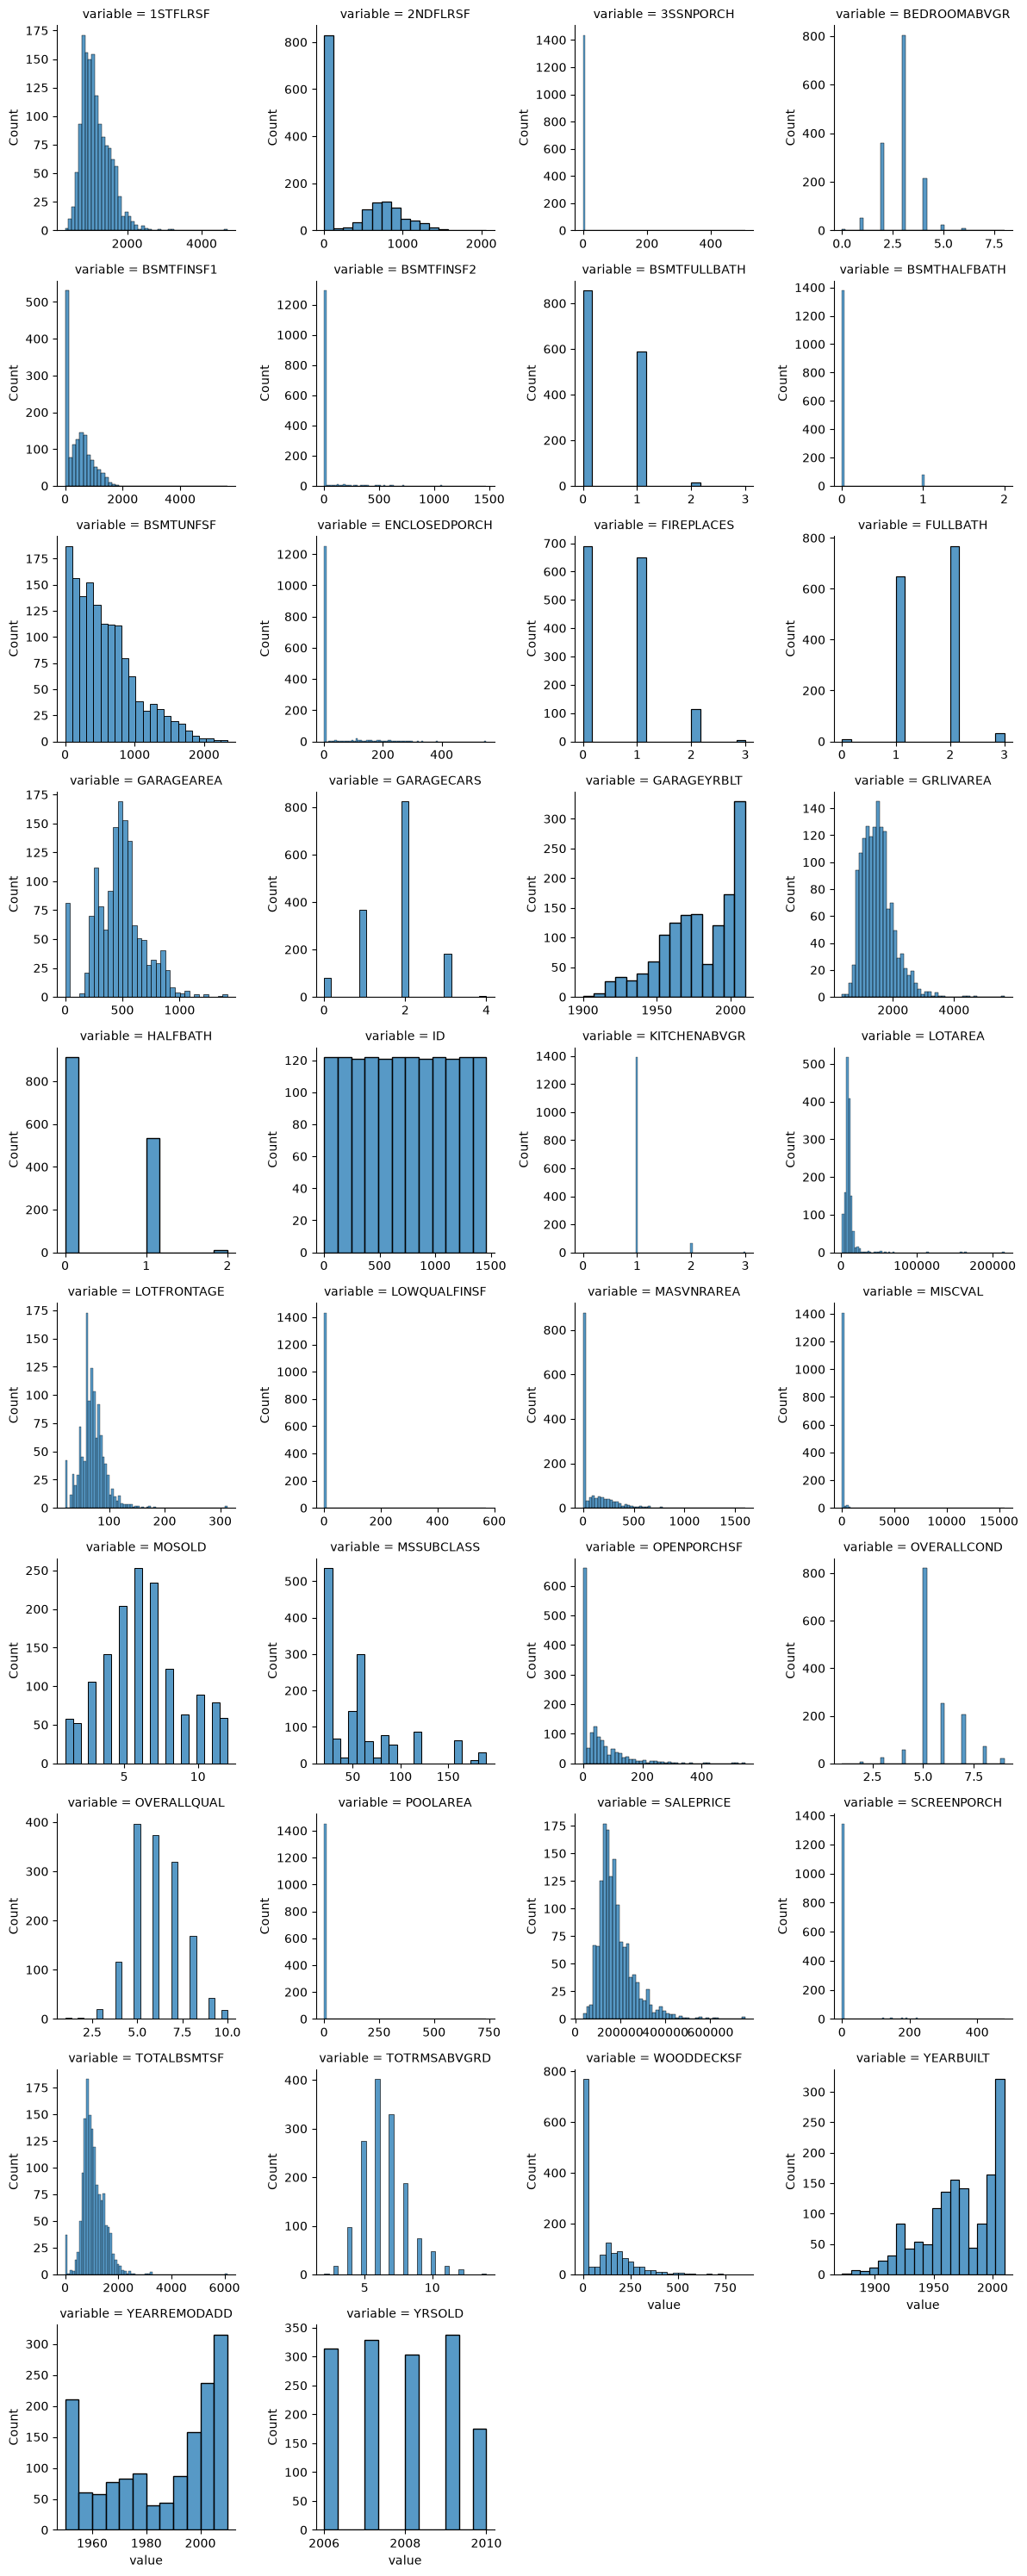

In [162]:
# NUMERIC COLUMNS DISTRIBUTION
numerical_columns = df.select_dtypes(include='int64') + df.select_dtypes(include='float64')
sns.FacetGrid(pd.melt(df, value_vars=numerical_columns), col="variable",  col_wrap=4, sharex=False, sharey=False).map(sns.histplot, "value")

**FLAG SPECIFIC COLUMNS**

- LOTAREA (concentrated)
- BSMTFINSF2 (presence of outliers)
- 1STFLRSF (presence of outliers)
- LOWQUALFINSF (concentrated + presence of outliers)
- GRLIVAREA (presence of outlier)
- BSMTHALFBATH (concentrated)
- KITCHENABVGR (concentrated)
- OPENPORCHSF (concentrated + presence of outliers)
- ENCLOSEDPORCH (concentrated + presence of outliers)
- 3SSNPORCH (concentrated + presence of outliers)
- SCREENPORCH (concentrated + presence of outliers)
- POOLAREA (concentrated + presence of outliers)
- MISCVAL (concentrated + presence of outliers)
- SALEPRICE (presence of outliers)

In [163]:
skewness_dict = {}
for col in numerical_columns.columns:
    skewness = float(df[col].skew())
    skewness_dict[col] = skewness

skewness_df = pd.DataFrame.from_dict(skewness_dict, orient='index')
skewness_df = skewness_df.rename(columns={0: 'SKEWNESS', 'index': 'CATEGORY'})
skewness_df = skewness_df.sort_values(by='SKEWNESS', ascending=False)


skewness_df

,SKEWNESS
MISCVAL,24.476794
POOLAREA,14.828374
LOTAREA,12.207688
3SSNPORCH,10.304342
LOWQUALFINSF,9.011341
KITCHENABVGR,4.488397
BSMTFINSF2,4.255261
SCREENPORCH,4.122214
BSMTHALFBATH,4.103403
ENCLOSEDPORCH,3.089872


In [164]:
approximately_symmetric = (skewness_df[(skewness_df['SKEWNESS'] < 0.5) & (skewness_df['SKEWNESS'] > -0.5)]).index
high_skew = (skewness_df[(skewness_df['SKEWNESS'] > 1.0) | (skewness_df['SKEWNESS'] < -1.0)]).index
moderate_skew = (skewness_df[(skewness_df['SKEWNESS'] >= 0.5) & (skewness_df['SKEWNESS'] <= 1.0) | (skewness_df['SKEWNESS'] >= -1.0) & (skewness_df['SKEWNESS'] <= -0.5)]).index

## 6. Check relationships between columns

In [165]:
## CORRELATION WITH TARGET

df_correlation_target = df[numerical_columns.columns].copy().corr().round(4)

df_correlation_target = pd.DataFrame(abs(df_correlation_target['SALEPRICE'])).sort_values(by=['SALEPRICE'], ascending=False)

df_correlation_target.rename(columns={'SALEPRICE' : 'SALEPRICE_ABS'}).drop(index='SALEPRICE')

,SALEPRICE_ABS
OVERALLQUAL,0.7910
GRLIVAREA,0.7086
GARAGECARS,0.6404
GARAGEAREA,0.6234
TOTALBSMTSF,0.6136
1STFLRSF,0.6059
FULLBATH,0.5607
TOTRMSABVGRD,0.5337
YEARBUILT,0.5229
YEARREMODADD,0.5071


In [166]:
# MULTICOLLINEARITY ANALYSIS

df_multicollinearity_analysis = pd.DataFrame(np.tril(df[numerical_columns.columns].copy().corr().round(4), k=-1), index=numerical_columns.columns, columns=numerical_columns.columns)

high_multicollinearity = pd.DataFrame(df_multicollinearity_analysis.stack()).rename(columns={0: 'MULTICOLLINEARITY'})
high_multicollinearity = high_multicollinearity[high_multicollinearity['MULTICOLLINEARITY'] >0.75]

high_multicollinearity

,,MULTICOLLINEARITY
GARAGECARS,GARAGEAREA,0.8825
SALEPRICE,OVERALLQUAL,0.7910
TOTALBSMTSF,1STFLRSF,0.8195
TOTRMSABVGRD,GRLIVAREA,0.8255
YEARBUILT,GARAGEYRBLT,0.8257
